Epoch 1/50
66/66 [==============================] - 43s 403ms/step - loss: 6863.7256 - mae: 64.8527 - r2_keras: -1.3855 - val_loss: 8765.0498 - val_mae: 72.2758 - val_r2_keras: -1.6357
Epoch 2/50
66/66 [==============================] - 24s 365ms/step - loss: 5755.0654 - mae: 58.0262 - r2_keras: -0.9979 - val_loss: 7740.2554 - val_mae: 66.9337 - val_r2_keras: -1.2438
Epoch 3/50
66/66 [==============================] - 23s 355ms/step - loss: 4987.4531 - mae: 53.4752 - r2_keras: -0.7276 - val_loss: 6846.3867 - val_mae: 62.3829 - val_r2_keras: -0.9538
Epoch 4/50
66/66 [==============================] - 24s 369ms/step - loss: 4347.7202 - mae: 49.6277 - r2_keras: -0.5039 - val_loss: 6179.6797 - val_mae: 59.0434 - val_r2_keras: -0.7697
Epoch 5/50
66/66 [==============================] - 24s 365ms/step - loss: 3795.2424 - mae: 46.0311 - r2_keras: -0.3150 - val_loss: 5588.5107 - val_mae: 56.1655 - val_r2_keras: -0.6105
Epoch 6/50
66/66 [==============================] - 24s 357ms/step - loss: 

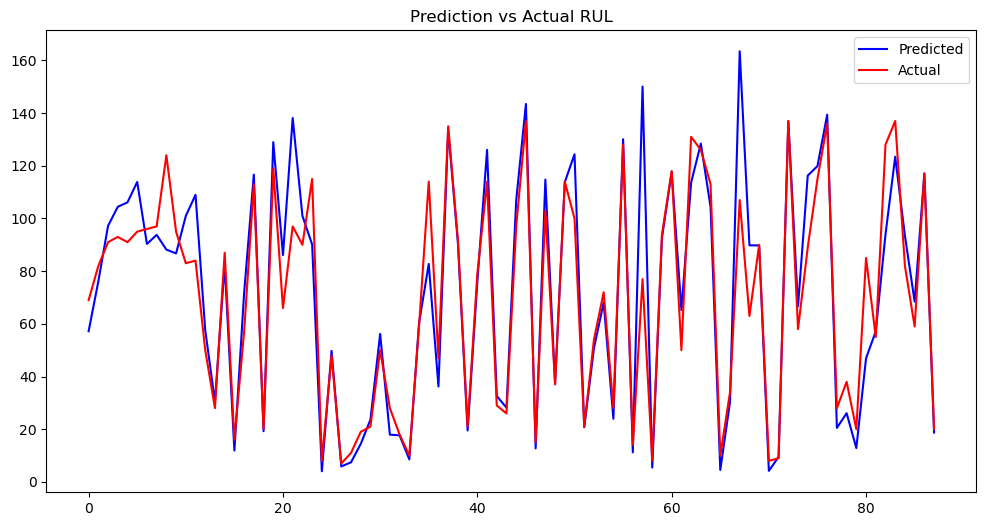

In [10]:

import os
import keras
import keras.backend as K
from keras.models import Sequential, load_model
from keras.layers import LSTM, Dense, Dropout, Bidirectional, Activation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing


np.random.seed(1234)
PYTHONHASHSEED = 0


train_path = "C:/Users/theta/Downloads/archive/CMaps/train_FD001.txt"
test_path = "C:/Users/theta/Downloads/archive/CMaps/test_FD001.txt"
rul_path = "C:/Users/theta/Downloads/archive/CMaps/RUL_FD001.txt"

train_df = pd.read_csv(train_path, sep=" ", header=None, engine='python')
test_df = pd.read_csv(test_path, sep=" ", header=None, engine='python')
truth_df = pd.read_csv(rul_path, sep=" ", header=None, engine='python')


train_df.drop(train_df.columns[[26, 27]], axis=1, inplace=True)
test_df.drop(test_df.columns[[26, 27]], axis=1, inplace=True)
truth_df.drop(truth_df.columns[[1]], axis=1, inplace=True)


train_df.columns = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]
test_df.columns = ['id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f's{i}' for i in range(1, 22)]


rul = pd.DataFrame(train_df.groupby('id')['cycle'].max()).reset_index()
rul.columns = ['id', 'max']
train_df = train_df.merge(rul, on='id', how='left')
train_df['RUL'] = train_df['max'] - train_df['cycle']
train_df.drop('max', axis=1, inplace=True)


cols_normalize = train_df.columns.difference(['id', 'cycle', 'RUL'])
scaler = preprocessing.MinMaxScaler()
norm_train_df = pd.DataFrame(scaler.fit_transform(train_df[cols_normalize]), columns=cols_normalize, index=train_df.index)
train_df = train_df[['id', 'cycle', 'RUL']].join(norm_train_df)


rul_test = pd.DataFrame(test_df.groupby('id')['cycle'].max()).reset_index()
rul_test.columns = ['id', 'max']
truth_df.columns = ['RUL']
truth_df['id'] = truth_df.index + 1
truth_df = truth_df.merge(rul_test, on='id', how='left')
truth_df['RUL'] += truth_df['max']
truth_df.drop('max', axis=1, inplace=True)
test_df = test_df.merge(truth_df, on='id', how='left')
test_df['RUL'] = test_df['RUL'] - test_df['cycle']
test_df = test_df[['id', 'cycle', 'RUL']].join(pd.DataFrame(scaler.transform(test_df[cols_normalize]), columns=cols_normalize, index=test_df.index))


sequence_length = 60
sensor_cols = [f's{i}' for i in range(1, 22)]
sequence_cols = ['setting1', 'setting2', 'setting3', 'cycle'] + sensor_cols

def gen_sequence(id_df, seq_length, seq_cols):
    data_matrix = id_df[seq_cols].values
    num_elements = data_matrix.shape[0]
    for start, stop in zip(range(0, num_elements - seq_length), range(seq_length, num_elements)):
        yield data_matrix[start:stop, :]

def gen_labels(id_df, seq_length, label_col):
    data_matrix = id_df[label_col].values
    return data_matrix[seq_length:]

 
seq_gen = (list(gen_sequence(train_df[train_df['id'] == id], sequence_length, sequence_cols)) for id in train_df['id'].unique())
seq_array = np.concatenate(list(seq_gen)).astype(np.float32)
label_gen = [gen_labels(train_df[train_df['id'] == id], sequence_length, 'RUL') for id in train_df['id'].unique()]
label_array = np.concatenate(label_gen).astype(np.float32)


model_bilstm = Sequential()
model_bilstm.add(Bidirectional(LSTM(units=100, return_sequences=True, input_shape=(sequence_length, seq_array.shape[2]))))
model_bilstm.add(Dropout(0.3))
model_bilstm.add(Bidirectional(LSTM(units=60, return_sequences=False)))
model_bilstm.add(Dropout(0.3))
model_bilstm.add(Dense(units=1))
model_bilstm.add(Activation("linear"))

def r2_keras(y_true, y_pred):
    SS_res = K.sum(K.square(y_true - y_pred))
    SS_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - SS_res / (SS_tot + K.epsilon())

model_bilstm.compile(loss='mean_squared_error', optimizer='rmsprop', metrics=['mae', r2_keras])


history_bilstm = model_bilstm.fit(seq_array, label_array, epochs=50, batch_size=200, validation_split=0.1, verbose=1,
                                  callbacks=[
                                      keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, mode='min'),
                                      keras.callbacks.ModelCheckpoint('bilstm_model.h5', monitor='val_loss', save_best_only=True, mode='min')
                                  ])


train_scores = model_bilstm.evaluate(seq_array, label_array, verbose=1, batch_size=200)
print(f"\nBiLSTM Train MAE: {train_scores[1]}, Train R²: {train_scores[2]}")


seq_array_test_last = []
label_array_test_last = []

for id in test_df['id'].unique():
    engine_data = test_df[test_df['id'] == id]
    if len(engine_data) >= sequence_length:
        
        seq_array_test_last.append(engine_data[sequence_cols].values[-sequence_length:])
        
        label_array_test_last.append(engine_data['RUL'].iloc[-1])


seq_array_test_last = np.asarray(seq_array_test_last).astype(np.float32)
label_array_test_last = np.asarray(label_array_test_last).astype(np.float32)

print("Shape of test sequences:", seq_array_test_last.shape)
print("Shape of test labels:", label_array_test_last.shape)


test_scores = model_bilstm.evaluate(seq_array_test_last, label_array_test_last, verbose=1)
print(f"\nBiLSTM Test MAE: {test_scores[1]}, Test R²: {test_scores[2]}")


y_pred_test = model_bilstm.predict(seq_array_test_last)
plt.figure(figsize=(12, 6))
plt.plot(y_pred_test, label='Predicted', color='blue')
plt.plot(label_array_test_last, label='Actual', color='red')
plt.title('Prediction vs Actual RUL')
plt.legend()
plt.show()



In [43]:
print(train_df)
print(test_df)
print(len(val))
print(seq_array.shape)
print(label_array.shape)
print(label_array[:10])
print("\nBiLSTM Model Summary:")
model_bilstm.summary()

        id  cycle  setting1  setting2  setting3   s1        s2        s3  \
0        1      1  0.459770  0.166667       0.0  0.0  0.183735  0.406802   
1        1      2  0.609195  0.250000       0.0  0.0  0.283133  0.453019   
2        1      3  0.252874  0.750000       0.0  0.0  0.343373  0.369523   
3        1      4  0.540230  0.500000       0.0  0.0  0.343373  0.256159   
4        1      5  0.390805  0.333333       0.0  0.0  0.349398  0.257467   
...    ...    ...       ...       ...       ...  ...       ...       ...   
20626  100    196  0.477011  0.250000       0.0  0.0  0.686747  0.587312   
20627  100    197  0.408046  0.083333       0.0  0.0  0.701807  0.729453   
20628  100    198  0.522989  0.500000       0.0  0.0  0.665663  0.684979   
20629  100    199  0.436782  0.750000       0.0  0.0  0.608434  0.746021   
20630  100    200  0.316092  0.083333       0.0  0.0  0.795181  0.639634   

             s4   s5  ...       s14       s15  s16       s17  s18  s19  \
0      0.3097

In [12]:
from sklearn.metrics import f1_score


threshold = 30


y_pred_binary = (y_pred_test.flatten() < threshold).astype(int)
y_true_binary = (label_array_test_last < threshold).astype(int)


f1 = f1_score(y_true_binary, y_pred_binary)
print(f"F1 Score: {f1:.4f}")


F1 Score: 0.9388


3/3 [==============================] - 0s 39ms/step
Mean Absolute Error (MAE): 10.0464
Root Mean Squared Error (RMSE): 16.1624
R² Score: 0.8445
Mean Absolute Percentage Error (MAPE): 16.59%
F1 Score: 0.9388


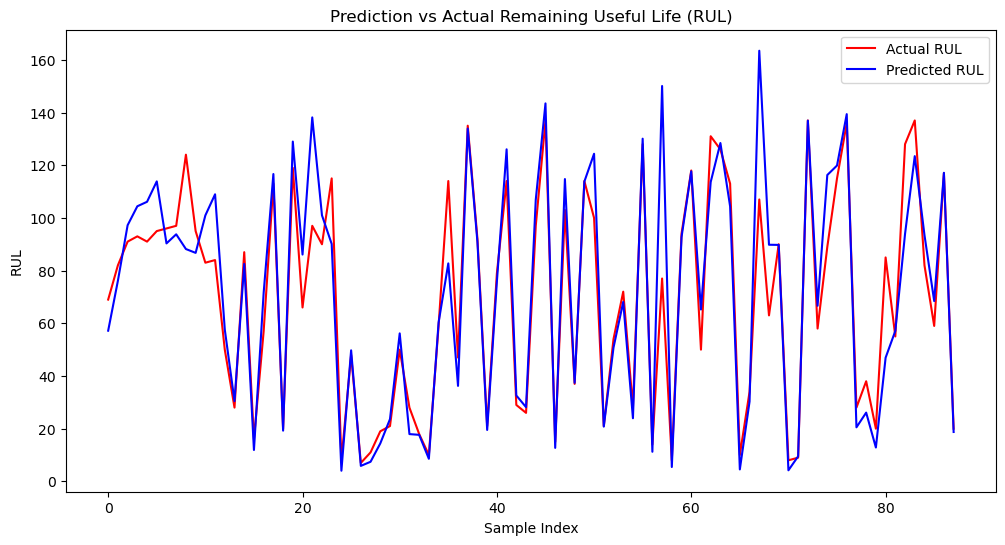

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


y_true = label_array_test_last
y_pred = model_bilstm.predict(seq_array_test_last).flatten()


mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100


threshold = 30  
y_true_binary = (y_true <= threshold).astype(int)
y_pred_binary = (y_pred <= threshold).astype(int)
f1 = f1_score(y_true_binary, y_pred_binary)


print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"F1 Score: {f1:.4f}")


import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_true, label='Actual RUL', color='red')
plt.plot(y_pred, label='Predicted RUL', color='blue')
plt.title('Prediction vs Actual Remaining Useful Life (RUL)')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.show()


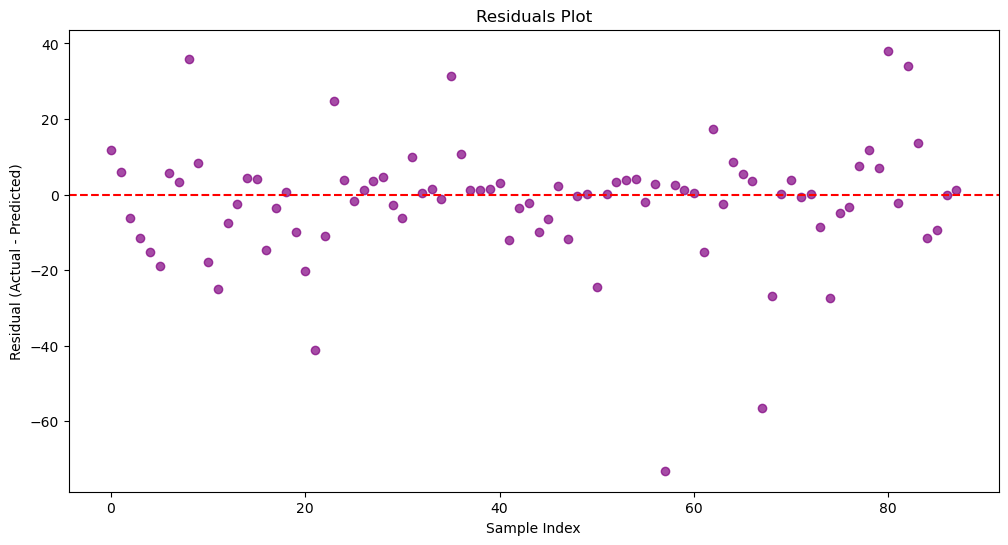

In [18]:
residuals = y_true - y_pred

plt.figure(figsize=(12, 6))
plt.scatter(range(len(residuals)), residuals, alpha=0.7, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residuals Plot')
plt.xlabel('Sample Index')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()


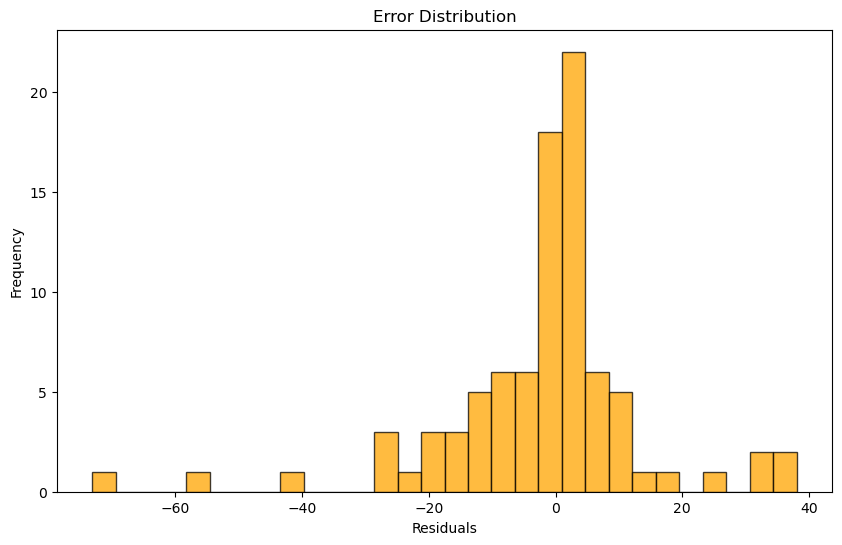

In [20]:
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=30, alpha=0.75, color='orange', edgecolor='black')
plt.title('Error Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()


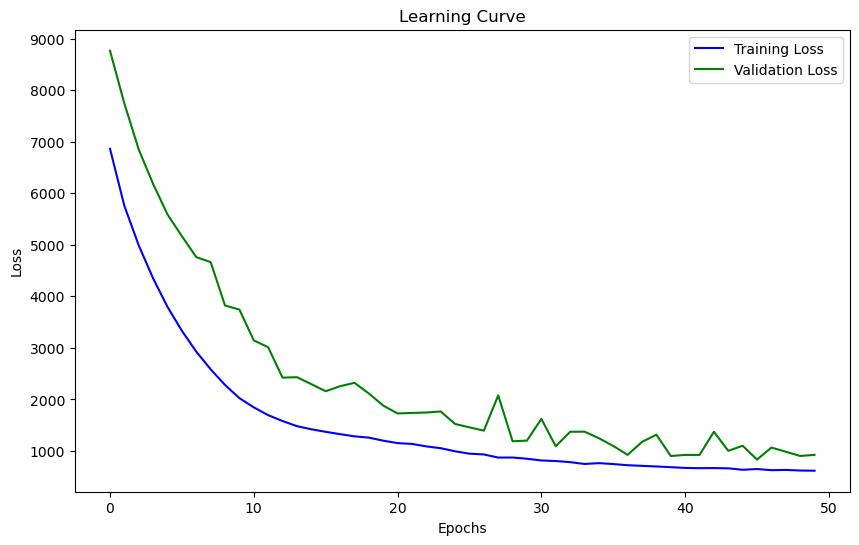

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(history_bilstm.history['loss'], label='Training Loss', color='blue')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss', color='green')
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


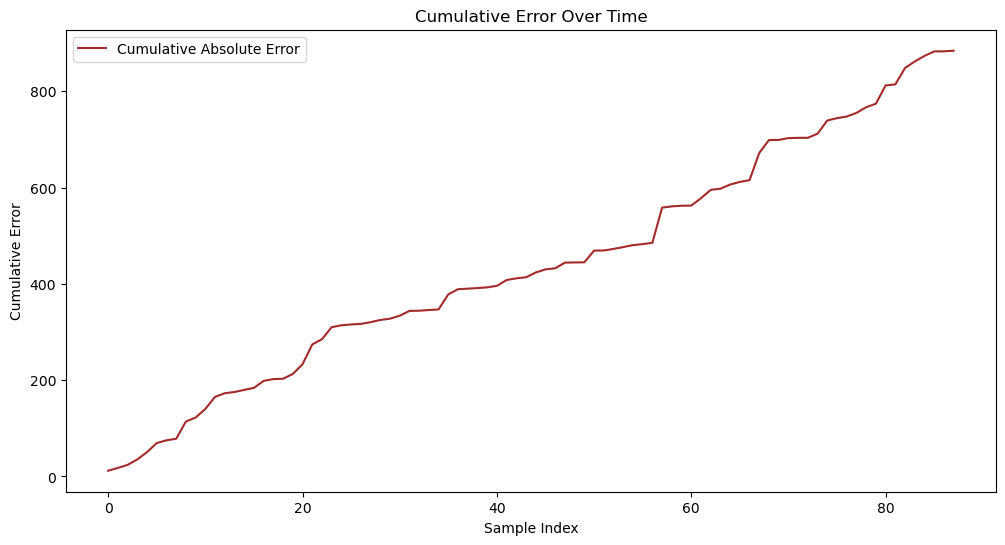

In [30]:
cumulative_error = np.cumsum(np.abs(residuals))

plt.figure(figsize=(12, 6))
plt.plot(cumulative_error, label='Cumulative Absolute Error', color='brown')
plt.title('Cumulative Error Over Time')
plt.xlabel('Sample Index')
plt.ylabel('Cumulative Error')
plt.legend()
plt.show()


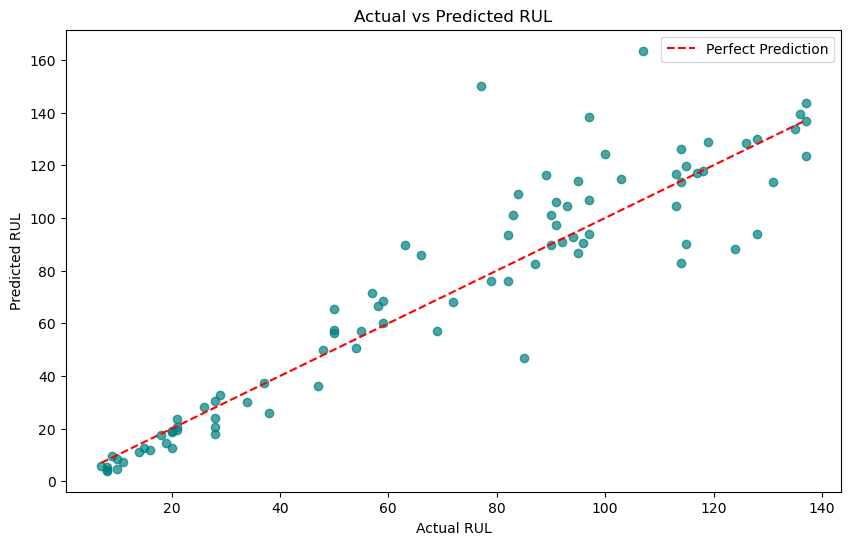

In [32]:
plt.figure(figsize=(10, 6))
plt.scatter(y_true, y_pred, alpha=0.7, color='teal')
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label='Perfect Prediction')
plt.title('Actual vs Predicted RUL')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.legend()
plt.show()


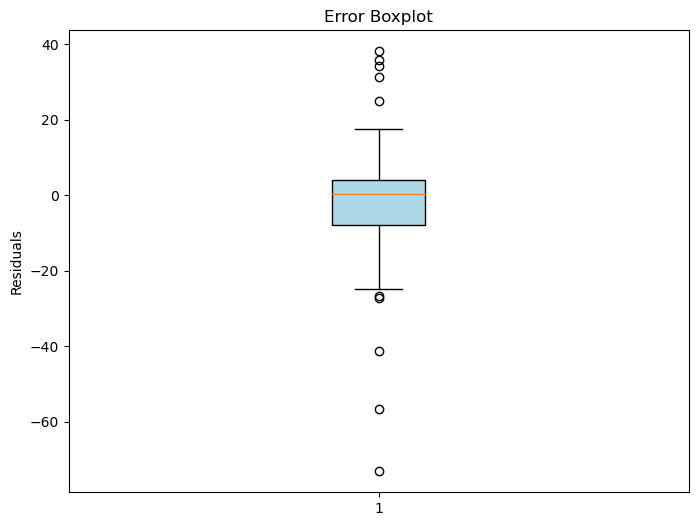

In [34]:
plt.figure(figsize=(8, 6))
plt.boxplot(residuals, patch_artist=True, boxprops=dict(facecolor='lightblue'))
plt.title('Error Boxplot')
plt.ylabel('Residuals')
plt.show()


In [44]:
import pandas as pd


metrics_data = {
    "Metric": ["Mean Absolute Error (MAE)", "Root Mean Squared Error (RMSE)", 
               "R² Score", "Mean Absolute Percentage Error (MAPE)", "F1 Score"],
    "Value": [10.0464, 16.1624, 0.8445, "16.59%", 0.9388]
}


metrics_df = pd.DataFrame(metrics_data)


print("Performance Metrics Table")
print(metrics_df)


Performance Metrics Table
                                  Metric    Value
0              Mean Absolute Error (MAE)  10.0464
1         Root Mean Squared Error (RMSE)  16.1624
2                               R² Score   0.8445
3  Mean Absolute Percentage Error (MAPE)   16.59%
4                               F1 Score   0.9388
